# Component Interface Tutorial

The goal of this tutorial is to demonstrate the highly modular component interface of the SPDE
prior subpackage. This low-level interface is not the most convenient way to construct prior
distributions, but it is extremely flexible with respect to user-defined extensions. In addition,
it helps in understanding the underlying structure of the package, and the mathematical approach it
is based on.

## Imports and Configuration

We import `DOLFINx` and `PETSc` for finite element assembly and linear algebra, and the
`components`, `fem`, and
`spde_prior` modules from `ls_bayesian`.

In [1]:
import dolfinx as dlx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from dolfinx.fem import petsc
from mpi4py import MPI
from petsc4py import PETSc

from ls_bayesian.spde_prior import components, fem, spde_prior

sns.set_theme(style="ticks")

## Define a DolfinX Mesh

The SPDE prior subpackage deals with the generation of prior distributions for function space
objects, i.e. functions defined on some domain $\Omega$, which might either be Euclidean, or an
embedded manifold, with topological dimension $d$. The most important input for the construction of
a prior distribution is therefore a computational mesh resembling the discretization of $\Omega$.
`ls_bayesian` requires input meshes in
[DOLFINx](https://docs.fenicsproject.org/dolfinx/main/python/generated/dolfinx.mesh.html) format.
Such meshes can easily be obtained from other common mesh formats, such as
[GMSH](https://gmsh.info/).

We set up a simple square mesh with `DOLFINx` for now. Note that we pass an MPI communicator to the
mesh; this communicator is used by all components of the SPDE prior subpackage for MPI-parallel
computations. Furthermore, while internal computations are performed on a finite element space (to
be defined below), the interface of prior objects works entirely via vectors defined on the
vertices of the provided mesh. This makes it easy to interface prior objects with other components
in an inverse problem workflow, without relying on the specific finite element representation.

In [2]:
mesh = dlx.mesh.create_rectangle(
    MPI.COMM_WORLD,
    [np.array([0, 0]), np.array([1, 1])],
    [100, 100],
    dlx.mesh.CellType.triangle,
)

## Define Necessary Settings for Prior Components

On the base level of the prior construction, we define FEM-specific data structures. Recall that we
construct prior distributions whose realizations $m$ satisfy, on the domain $\Omega$, SPDEs of the
form

$$
\begin{equation*}
    \tau(\kappa^2-\Delta)^{\frac{\nu}{2}}m(x) = W(x),\quad x\in\Omega
\end{equation*}
$$

where $\kappa,\tau > 0$ are parameters determining the variance and correlation properties of the
realizations, $\nu > \frac{d}{2}$ determines their regularity, and $W$ is spatial white noise on
$\Omega$. The SPDE can be equipped either with homogeneous Neumann boundary conditions,

$$
\begin{equation*}
    \nabla m(x)\cdot\mathbf{n}(x) = 0,\quad x\in\partial\Omega,
\end{equation*}
$$

or Robin boundary conditions of the form

$$
\begin{equation*}
    \nabla m(x)\cdot\mathbf{n}(x) + \beta m(x) = 0,\quad x\in\partial\Omega,
\end{equation*}
$$

where $\mathbf{n}$ is the outward unit normal vector of $\partial\Omega$, and $\beta$ is a scalar
tuning coefficient for the Robin condition.

For simplicity, we assume $\nu=2$, corresponding to the common *Bi-Laplace* prior scenario. We can
now (informally, as white noise $W$ is actually too irregular) write the SPDE in weak form against
suitable test functions $\varphi$,

$$
\begin{equation*}
    \kappa^2\tau(m,\varphi)_{L^2(\Omega)} + \tau (\nabla m,\nabla\varphi)_{L^2(\Omega)} + \beta(m,\varphi)_{L^2(\partial\Omega)} = (W,\varphi)_{L^2(\Omega)}.
\end{equation*}
$$

To recover Neumann boundary conditions, we simply set $\beta=0$. In particular, we are interested
in the left-hand-side operator $\mathcal{A}$ defined via

$$
\begin{equation*}
    \mathcal{A}m = \kappa^2\tau(m,\varphi)_{L^2(\Omega)} + \tau (\nabla m,\nabla\varphi)_{L^2(\Omega)} + \beta(m,\varphi)_{L^2(\partial\Omega)},
\end{equation*}
$$

and the "mass matrix operator" $\mathcal{M}$ defined via

$$
\begin{equation*}
    \mathcal{M}m = (m,\varphi)_{L^2(\Omega)}.
\end{equation*}
$$

Below, we fix $\kappa$ and $\tau$, the mean vector $\overline{\mathbf{m}}$ (in vertex-based form),
and the finite element function space on which these operators will be discretized. We also
configure the
`InverseMatrixSolverSettings` for
the matrix-free inversion of the discretized operators $\mathcal{M}$ and $\mathcal{A}$, further
below: a standard CG solver with Jacobi preconditioning for the $\mathbf{M}$-solver, and AMG
preconditioning for the $\mathbf{A}$-solver.

In [3]:
kappa, tau = 10.0, 0.1
mean_vector = np.zeros(mesh.geometry.x.shape[0], dtype=np.float64)
function_space = dlx.fem.functionspace(mesh, ("Lagrange", 2))

cg_solver_settings = components.InverseMatrixSolverSettings(
    solver_type=PETSc.KSP.Type.CG,
    preconditioner_type=PETSc.PC.Type.JACOBI,
    relative_tolerance=1e-6,
    absolute_tolerance=1e-8,
    max_num_iterations=10000,
)

amg_solver_settings = components.InverseMatrixSolverSettings(
    solver_type=PETSc.KSP.Type.CG,
    preconditioner_type=PETSc.PC.Type.GAMG,
    relative_tolerance=1e-6,
    absolute_tolerance=1e-8,
    max_num_iterations=10000,
)

## Assemble FEM Structures

These operators can be discretized on a finite-dimensional subspace $V_h$ according to the standard
finite element procedure. We do this with `DOLFINx` by first calling
`generate_forms`, which, given the parametrization and
FEM function space, returns [UFL](https://fenics.readthedocs.io/projects/ufl/en/latest/) forms
corresponding to $\mathcal{M}$ and $\mathcal{A}$. We then assemble these forms into sparse
[`PETSc` matrices](https://petsc.org/release/petsc4py/reference/petsc4py.PETSc.Mat.html)
$\mathbf{M}$ and $\mathbf{A}$.

!!! info
    We assemble the matrices $\mathbf{M}$ and $\mathbf{A}$ under the premise that $\nu=2$. These
    matrices can be used, however, as building blocks for fields of other orders $\nu$ as well.

To generate samples from a prior distribution, we further require a factorization of $\mathbf{M}$,
i.e. a matrix $\widehat{\mathbf{M}}$ such that
$\widehat{\mathbf{M}}\widehat{\mathbf{M}}^T=\mathbf{M}$. Such a factorization can be constructed
efficiently and in sparse form, exploiting the finite element assembly procedure. `ls_bayesian`
provides this functionality in the
`FEMMatrixFactorizationAssembler`
class. Given the mesh, the FE function space, and a weak form, the factorization assembler
generates two sparse `PETSc` matrices $\widehat{\mathbf{M}}_e$ and $\mathbf{L}$, such that
$\widehat{\mathbf{M}} = \mathbf{L}^T\widehat{\mathbf{M}}_e$. For more detail, we refer to the
[class documentation][ls_bayesian.spde_prior.fem.FEMMatrixFactorizationAssembler].

Lastly, we initialize a `FEMConverter` object, which
takes care of the conversion between vectors defined on mesh vertices and the internal
representation on the function space DoFs.

In [4]:
mass_matrix_form, spde_matrix_form = fem.generate_forms(function_space, kappa, tau)
mass_matrix = petsc.assemble_matrix(dlx.fem.form(mass_matrix_form))
spde_matrix = petsc.assemble_matrix(dlx.fem.form(spde_matrix_form))
mass_matrix.assemble()
spde_matrix.assemble()
mass_matrix_factorization = fem.FEMMatrixFactorizationAssembler(
    mesh, function_space, mass_matrix_form
)
block_diagonal_matrix, dof_map_matrix = mass_matrix_factorization.assemble()
dof_map_matrix.transpose()
converter = fem.FEMConverter(function_space)

## Assemble Elementary PETSc Components

Given the underlying FEM matrices, we can start climbing up the `ls_bayesian` component hierarchy.
All components we use to construct the prior adhere to the
`PETScComponent` interface. This uniform
interface allows for the arbitrary composition of PETSc components, resulting in new such
components.

In a first step, we initialize the components that resemble the action of the FEM matrices, as well
as their inverses, on vectors of matching size. The matrices $\mathbf{M}$, $\mathbf{A}$,
$\widehat{\mathbf{M}}_e$, and $\mathbf{L}$ are wrapped as
`Matrix` components -- thin wrappers around the
standard `PETSc` matrix interface. Next, we represent the action of the inverse matrices
$\mathbf{M}^{-1}$ and $\mathbf{A}^{-1}$ via
`InverseMatrixSolver` components, using
the settings configured above. Under the hood, these components use `PETSc`'s
[Krylov subspace solvers](https://petsc.org/release/petsc4py/reference/petsc4py.PETSc.KSP.html) and
[preconditioners](https://petsc.org/release/petsc4py/reference/petsc4py.PETSc.PC.html) for
matrix-free inversion of the provided input matrices.

In [5]:
mass_matrix_component = components.Matrix(mass_matrix)
spde_matrix_component = components.Matrix(spde_matrix)
block_diagonal_matrix_component = components.Matrix(block_diagonal_matrix)
dof_map_matrix_component = components.Matrix(dof_map_matrix)
mass_matrix_inverse_component = components.InverseMatrixSolver(cg_solver_settings, mass_matrix)
spde_matrix_inverse_component = components.InverseMatrixSolver(amg_solver_settings, spde_matrix)

## Assemble Composite PETSc Components

As mentioned above, we can combine arbitrary
`PETScComponent` objects into new ones, relying
on the
`PETScComponentComposition` class.
Objects of this type simply chain calls to all sub-components they comprise, in the order they have
been provided. This means we could chain covariance operators for arbitrary, also fractional, order
$\nu$, e.g. by using a spectral decomposition algorithm on the basic components, and wrapping it in
another `PETScComponent`.

We again focus on the case $\nu=2$, i.e. the Bilaplace prior. The discrete covariance and precision
matrices are then given as

$$
\begin{gather*}
    \mathbf{C} = \mathbf{A}^{-1}\mathbf{M}\mathbf{A}^{-1} \\
    \mathbf{C}^{-1} = \mathbf{A}\mathbf{M}^{-1}\mathbf{A}
\end{gather*}
$$

The factorization of the covariance matrix is given accordingly,

$$
\begin{equation*}
    \widehat{\mathbf{C}} = \mathbf{A}^{-1}\widehat{\mathbf{M}} = \mathbf{A}^{-1}\mathbf{L}^T\widehat{\mathbf{M}}_e.
\end{equation*}
$$

The action of these components is conveniently wrapped below as the precision operator, covariance
operator, and sampling factor.

In [6]:
precision_operator = components.PETScComponentComposition(
    spde_matrix_component, mass_matrix_inverse_component, spde_matrix_component
)
covariance_operator = components.PETScComponentComposition(
    spde_matrix_inverse_component, mass_matrix_component, spde_matrix_inverse_component
)
sampling_factor = components.PETScComponentComposition(
    block_diagonal_matrix_component,
    dof_map_matrix_component,
    spde_matrix_inverse_component,
)

## Set Up Interfaces

In a last step, we wrap the covariance, precision, and sampling factor by
`InterfaceComponent` objects. The interface
does not add any functionality, but is merely for convenience: it allows us to transition from a
more indirect, reference-based `PETSc` interface to a more explicit `Numpy` interface, so we don't
have to worry about components overwriting shared buffers internally.

In [7]:
precision_operator_interface = components.InterfaceComponent(precision_operator)
covariance_operator_interface = components.InterfaceComponent(covariance_operator)
sampling_factor_interface = components.InterfaceComponent(sampling_factor)

## Initialize Prior Object

We can now create an `SPDEPrior` object from the
assembled interfaces, the mean vector $\overline{\mathbf{m}}$ defined above, our
`FEMConverter` object, and a seed for the prior's
internal RNG.

In [8]:
bilaplace_prior = spde_prior.SPDEPrior(
    mean_vector,
    precision_operator_interface,
    covariance_operator_interface,
    sampling_factor_interface,
    converter,
    seed=0,
)

## Test Prior Functionality

To conclude this tutorial, let us briefly test the functionality provided by
`SPDEPrior` objects. As of now, the interface
provides the following methods:

1. `evaluate_cost`: compute the
   negative "log-probability" (a slight misnomer in the function space setting) for a given state
   $\mathbf{m}$, corresponding to a cost in the optimization context, i.e.
   $\frac{1}{2}(\mathbf{m}-\overline{\mathbf{m}})^T\mathbf{C}^{-1}(\mathbf{m}-\overline{\mathbf{m}})$.
2. `evaluate_gradient`: compute the
   derivative of the cost with respect to the state $\mathbf{m}$, i.e.
   $\mathbf{C}^{-1}(\mathbf{m}-\overline{\mathbf{m}})$.
3. `evaluate_hessian_vector_product`:
   evaluate the Hessian-vector product in a direction $\widehat{\mathbf{m}}$, i.e.
   $\mathbf{C}^{-1}\widehat{\mathbf{m}}$.
4. `generate_sample`: generate a
   sample $\widetilde{\mathbf{m}}$ from the prior distribution.

In [9]:
rng = np.random.default_rng(0)

test_vector_1 = rng.random(mean_vector.shape)
test_vector_2 = 2 * rng.random(mean_vector.shape)
test_vector_3 = 3 * rng.random(mean_vector.shape)

cost = bilaplace_prior.evaluate_cost(test_vector_1)
grad = bilaplace_prior.evaluate_gradient(test_vector_2)
hvp = bilaplace_prior.evaluate_hessian_vector_product(test_vector_3)
sample = bilaplace_prior.generate_sample()

## Visualize Sample

Let us also plot the sample over the square domain.

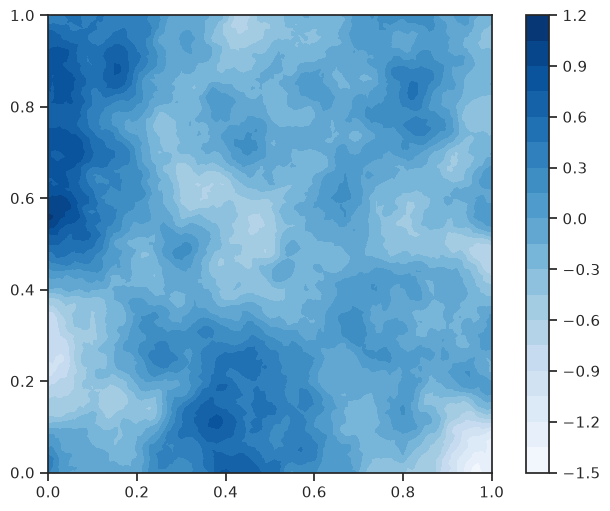

In [11]:
# `sample` is ordered by input node index (see fem.py), not dolfinx's internal geometry
# order, so the plotting coordinates must match that order.
vertices, _ = fem.get_ordered_vertices_and_cells(mesh)

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
contour_plot = ax.tricontourf(vertices[:, 0], vertices[:, 1], sample, levels=20, cmap="Blues")
plt.colorbar(contour_plot)